# Burst Experiment — Simplified 3-Phase Pipeline

Three independent phases:
1. **Pretrain** — train on background tasks until convergence (run once)
2. **Finetune** — burst phase with configurable concentration (sweep here)
3. **Forget** — reversion phase, measure how quickly burst knowledge is lost

Each phase saves checkpoints so you can re-run downstream phases without retraining upstream.

In [16]:
import sys, os
os.chdir("/workspace/compositional_capabilities_burst")
sys.path.insert(0, ".")
from simple import make_data, pretrain, finetune, forget, report, interp
import matplotlib.pyplot as plt
%matplotlib inline

OUT = "data/simple_burst"
SEED = 42  # change this to vary experiments

## 1. Generate Data

One call, reuse across all phases. Adjust `depth`, `burst_pos`, `n_a` to change task complexity.

In [17]:
data = make_data(depth=3, burst_pos=3, n_a=4, seed=SEED)
print(f"Vocab: {data['vocab_size']}, Context: {data['context_size']}, Prompt: {data['prompt_len']}")
print(f"Other tasks: {data['task_info']['n_other_tasks']}, Burst tasks: {data['task_info']['n_burst_tasks']}")

Vocab: 37, Context: 37, Prompt: 12
Other tasks: 64, Burst tasks: 16


## 2. Pretrain (run once)

Trains on background data until loss plateaus. Saves checkpoint to reuse.

Pretrain: 0it [00:00, ?it/s]


Converged at step 800 (eval loss plateaued for 5 checks)
Pretrain done: peak acc_other=1.0000, final loss_other=0.5822


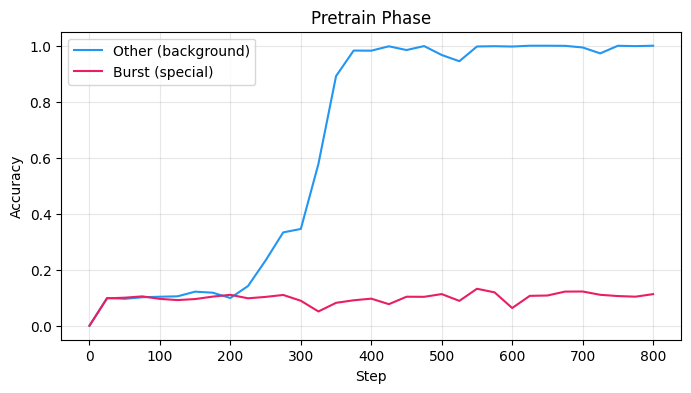

Checkpoint: data/simple_burst/pretrain/pretrain_ckpt.pt


In [18]:
pt = pretrain(data, f"{OUT}/pretrain", seed=SEED)
report.plot_pretrain(pt)
plt.show()
print(f"Checkpoint: {pt['ckpt_path']}")

## 3. Finetune — sweep over burst fractions

Each run loads the same pretrained checkpoint. Edit `FRACS` to test different concentrations.

In [19]:
import torch.multiprocessing as mp
from simple.finetune import _finetune_worker

FRACS = [1.0, 0.9, 0.8, 0.7, 0.6, 0.5, 0.4, 0.3, 0.2, 0.1]  # sweep these

jobs = [dict(data=data, pretrain_ckpt=pt["ckpt_path"], out_dir=f"{OUT}/finetune",
             burst_frac=frac, steps=600, seed=SEED, quiet=True)
        for frac in FRACS]

ctx = mp.get_context("spawn")
with ctx.Pool(len(FRACS)) as pool:
    ft_results = pool.map(_finetune_worker, jobs)

for r in ft_results:
    print(f"  {r['tag']}: peak_burst={r['peak_burst']:.3f}")

  burst_100: peak_burst=1.000
  burst_90: peak_burst=1.000
  burst_80: peak_burst=1.000
  burst_70: peak_burst=1.000
  burst_60: peak_burst=1.000
  burst_50: peak_burst=1.000
  burst_40: peak_burst=1.000
  burst_30: peak_burst=1.000
  burst_20: peak_burst=1.000
  burst_10: peak_burst=1.000


## 4. Forget — measure reversion for each finetuned model

In [20]:
from simple.forget import _forget_worker

jobs = [dict(data=data, finetune_ckpt=ft["ckpt_path"], out_dir=f"{OUT}/forget",
             pretrain_ckpt=pt["ckpt_path"], steps=300, seed=SEED, quiet=True)
        for ft in ft_results]

with ctx.Pool(len(ft_results)) as pool:
    fg_results = pool.map(_forget_worker, jobs)

for r in fg_results:
    print(f"  {r['tag']}: peak={r['peak_burst']:.3f} -> end={r['end_burst_acc']:.3f} "
          f"(drop {r['dropoff_pct']:.1f}%)")

  burst_100: peak=1.000 -> end=0.105 (drop 89.5%)
  burst_90: peak=1.000 -> end=0.194 (drop 80.6%)
  burst_80: peak=1.000 -> end=0.516 (drop 48.4%)
  burst_70: peak=1.000 -> end=0.435 (drop 56.5%)
  burst_60: peak=1.000 -> end=0.596 (drop 40.4%)
  burst_50: peak=1.000 -> end=0.519 (drop 48.1%)
  burst_40: peak=1.000 -> end=0.629 (drop 37.1%)
  burst_30: peak=1.000 -> end=0.561 (drop 43.9%)
  burst_20: peak=1.000 -> end=0.703 (drop 29.7%)
  burst_10: peak=1.000 -> end=0.747 (drop 25.3%)


## 5. Summary Table

In [21]:
# Summary table
rows = report.summary_table(ft_results, fg_results)

Tag             Burst%   Peak    End  Drop%      AUC 95%-life 80%-life
----------------------------------------------------------------------
burst_100         100%  1.000  0.105   89.5       45   25.000   25.000
burst_90           90%  1.000  0.194   80.6      107   25.000   25.000
burst_80           80%  1.000  0.516   48.4      166   25.000   50.000
burst_70           70%  1.000  0.435   56.5      190   25.000   50.000
burst_60           60%  1.000  0.596   40.4      243   50.000  150.000
burst_50           50%  1.000  0.519   48.1      230   75.000  150.000
burst_40           40%  1.000  0.629   37.1      254   50.000  175.000
burst_30           30%  1.000  0.561   43.9      222   50.000  100.000
burst_20           20%  1.000  0.703   29.7      237   25.000  150.000
burst_10           10%  1.000  0.747   25.3      261   75.000  200.000


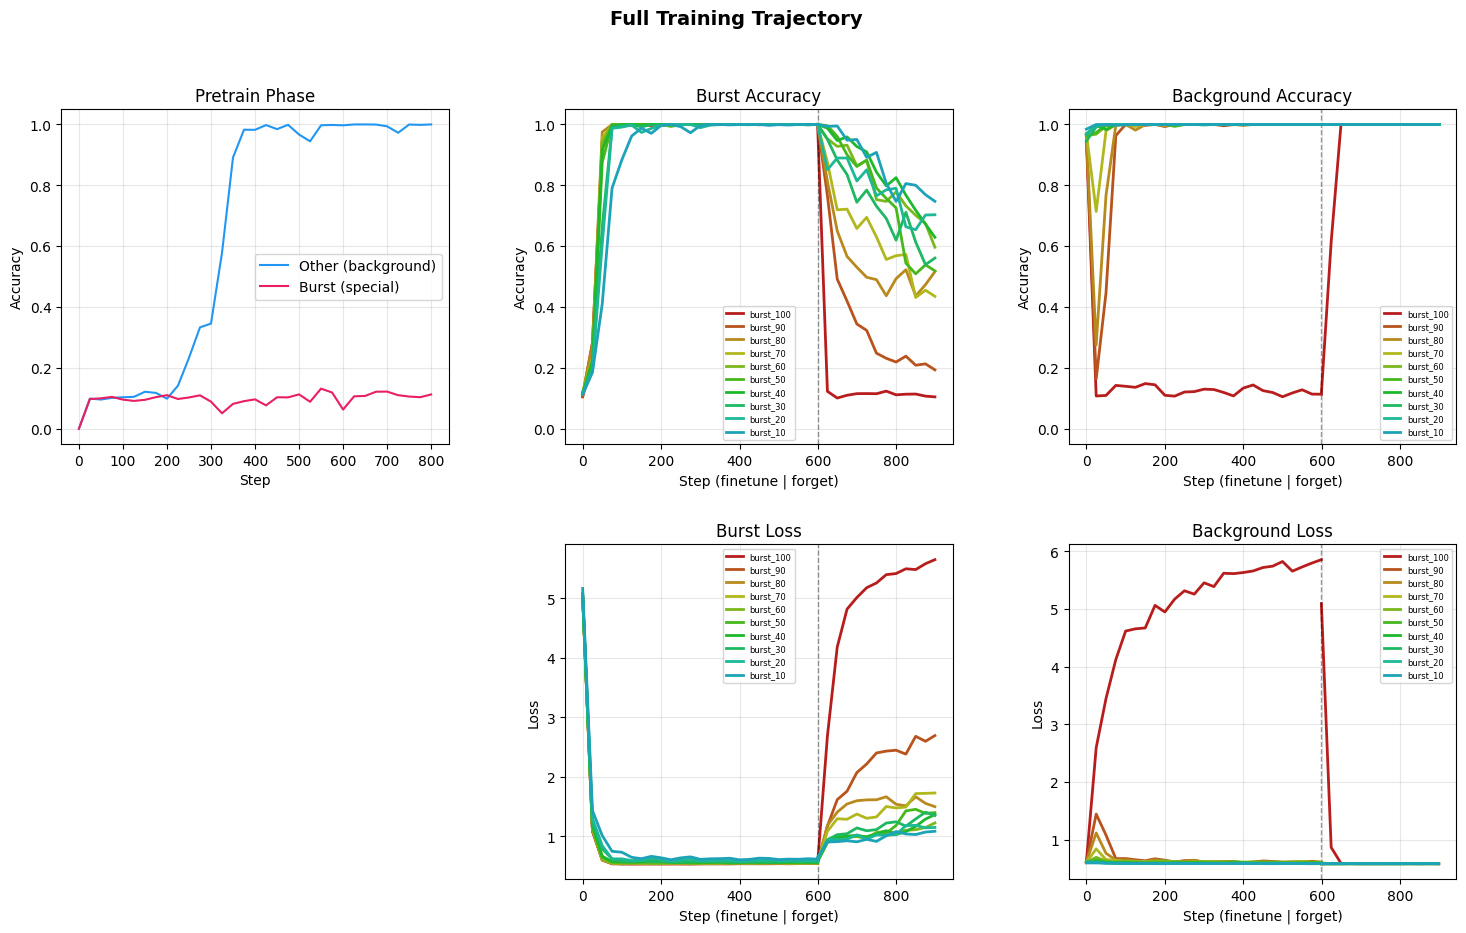

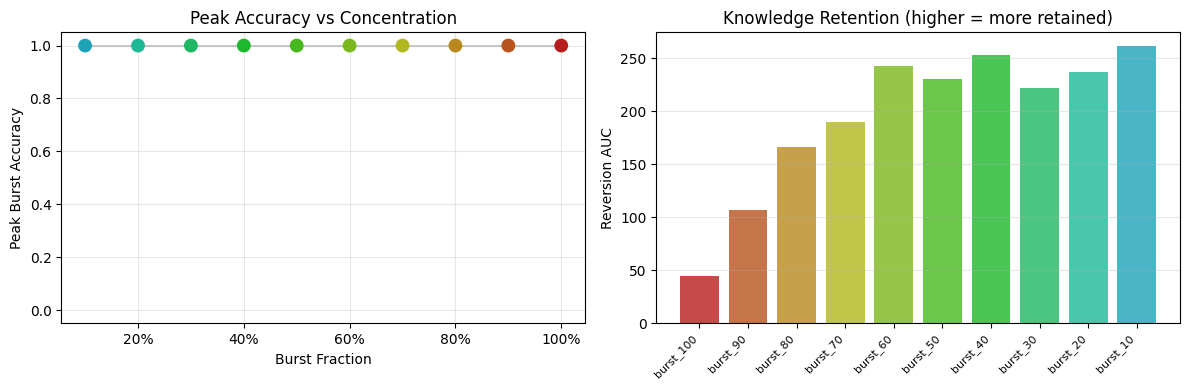

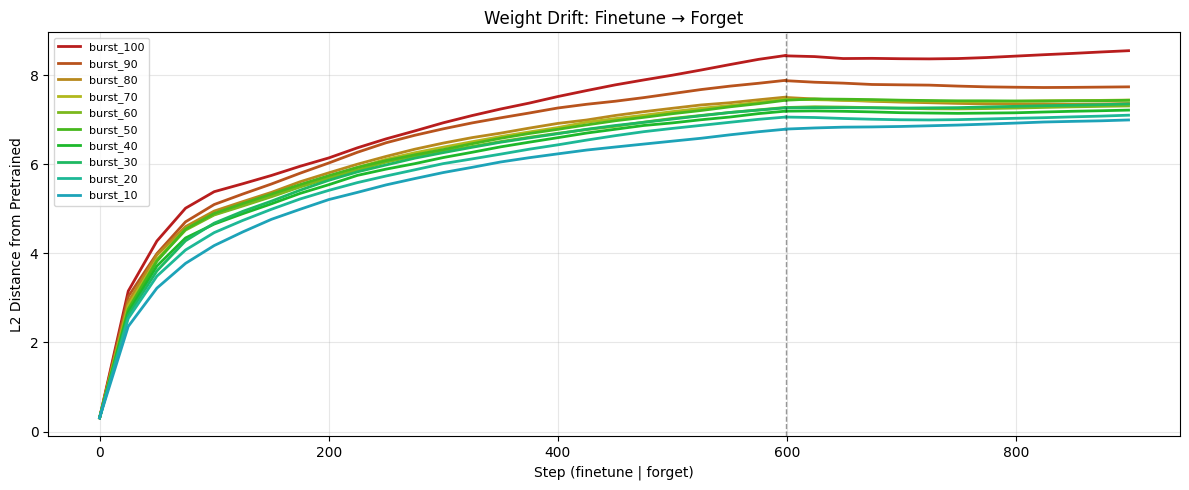

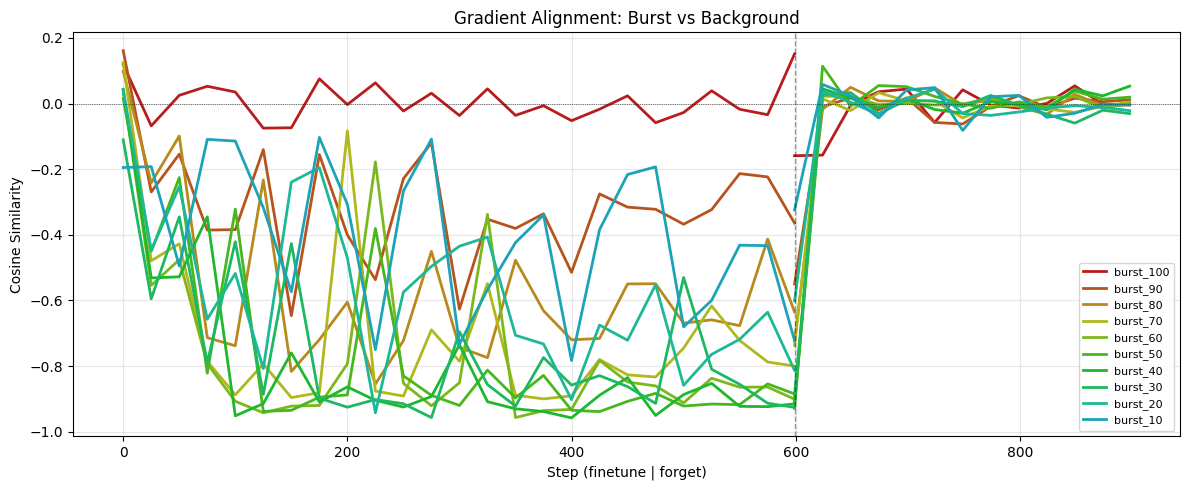

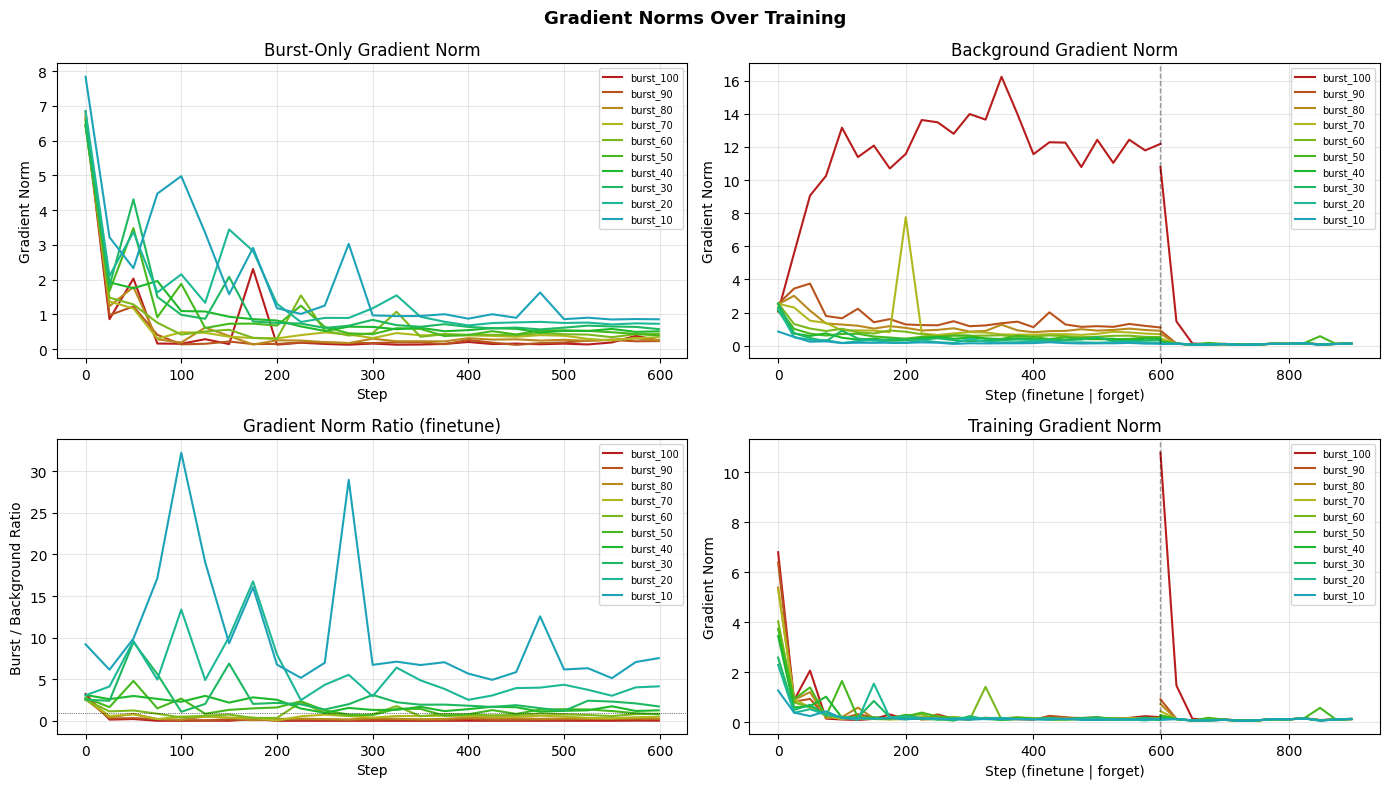

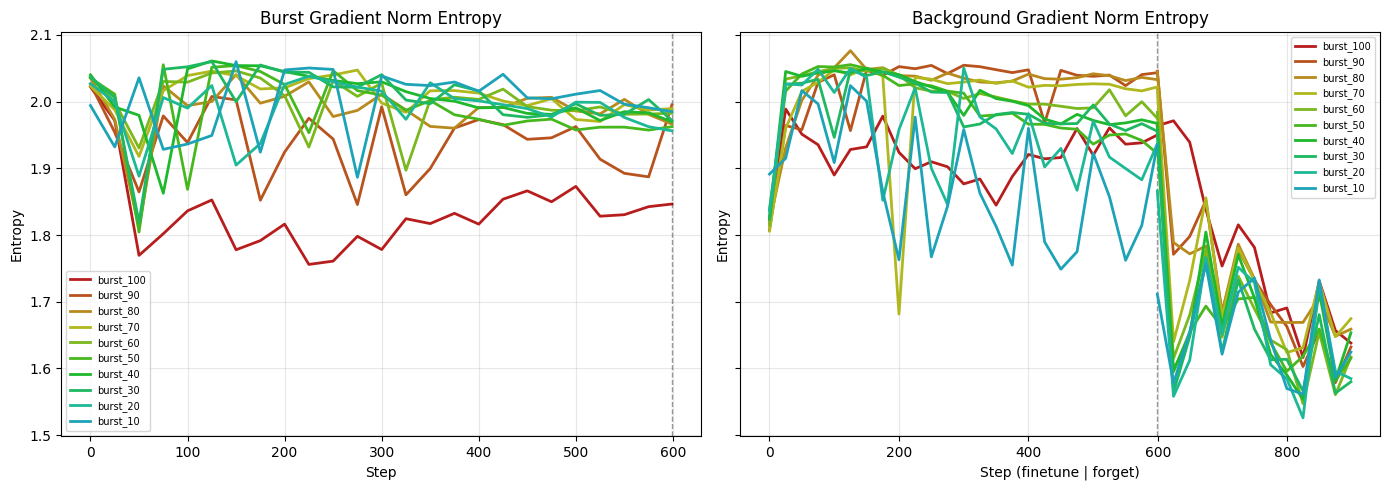

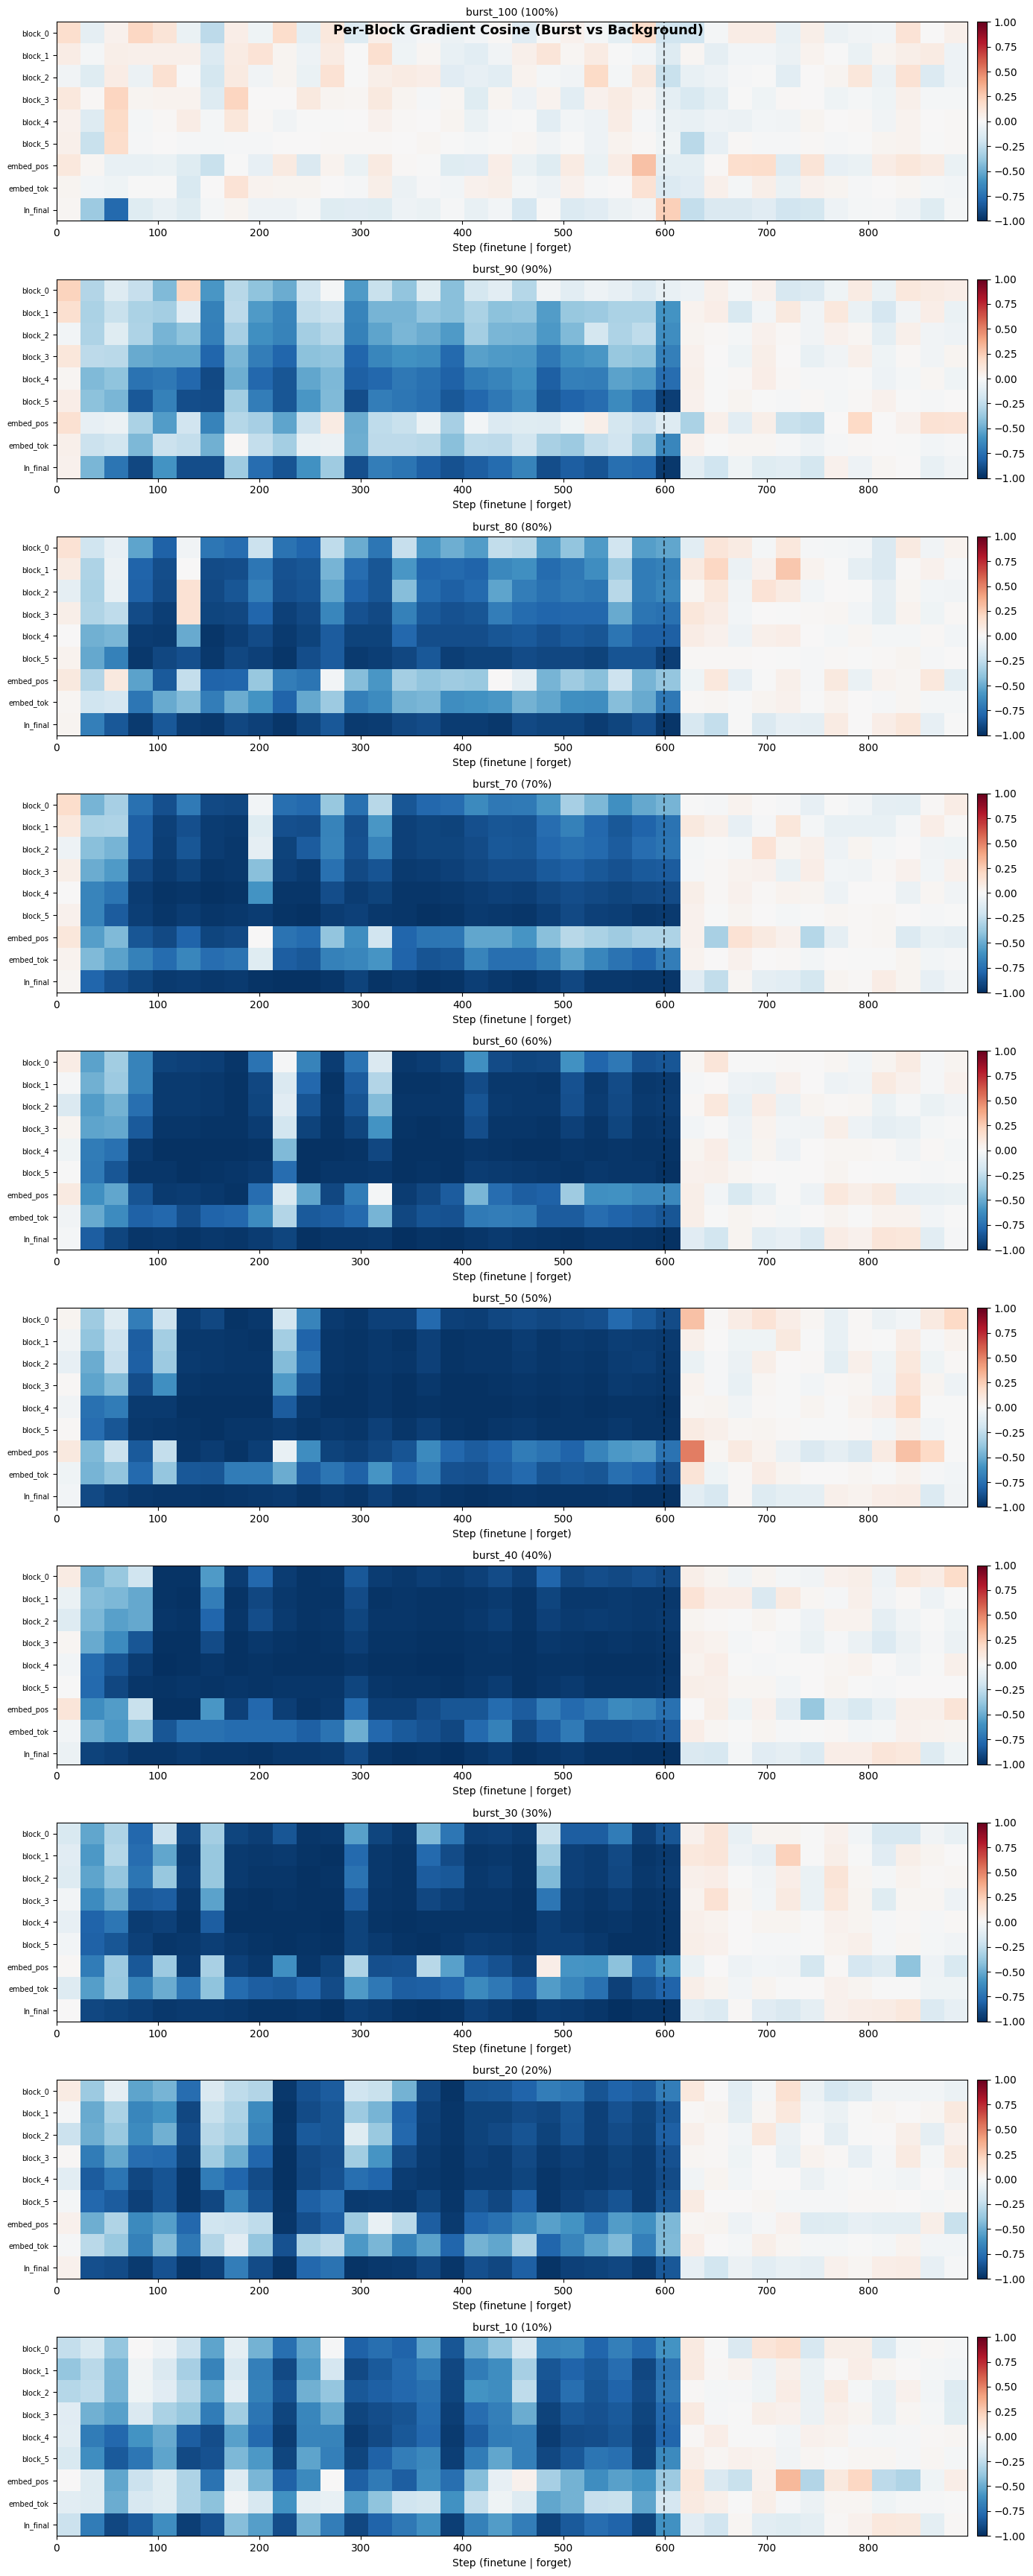

In [22]:
# Full trajectory: pretrain + continuous finetune→forget (acc + loss)
fig = report.plot_full_trajectory(pt, ft_results, fg_results)
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
report.plot_peak_vs_frac(ft_results, axes[0])
report.plot_retention_vs_frac(fg_results, axes[1])
fig.tight_layout()
plt.show()

# Weight drift: continuous finetune→forget
fig = report.plot_weight_drift(ft_results, fg_results)
plt.show()

# Gradient cosine: continuous finetune→forget
fig = report.plot_grad_cosine(ft_results, fg_results)
plt.show()

# Gradient norms: continuous where possible
fig = report.plot_grad_norms(ft_results, fg_results)
plt.show()

# Gradient norm entropy: how spread out are gradients across blocks?
fig = report.plot_grad_norm_entropy(ft_results, fg_results)
plt.show()

# Per-block gradient cosine heatmaps: continuous finetune→forget
fig = report.plot_grad_cosine_per_layer(ft_results, fg_results)
plt.show()

## 6. Interpretability Analysis

Post-hoc analysis of checkpoints: per-layer weight drift, SVD structure, CKA, per-layer gradient cosine heatmaps.

In [23]:
analysis = interp.analyze(data, pt, ft_results, fg_results)

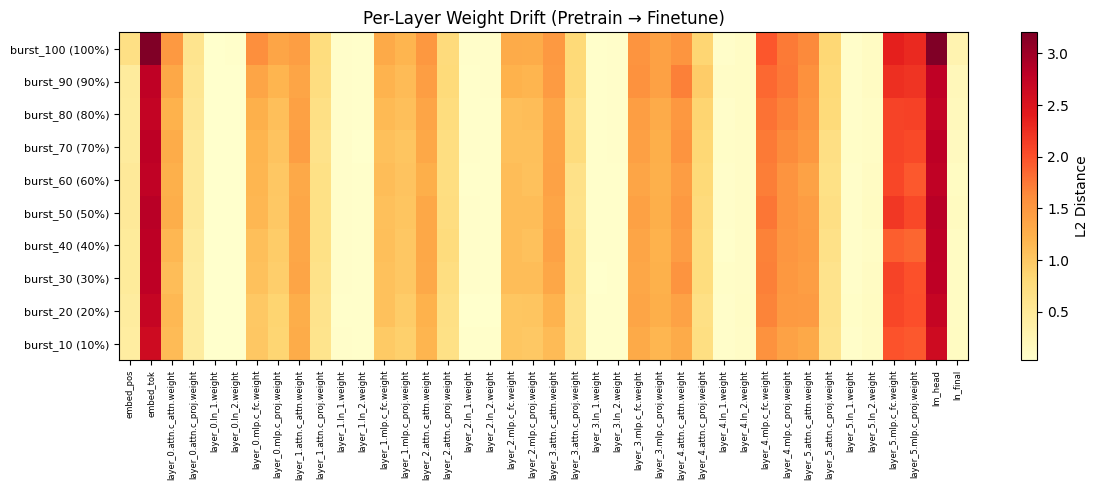

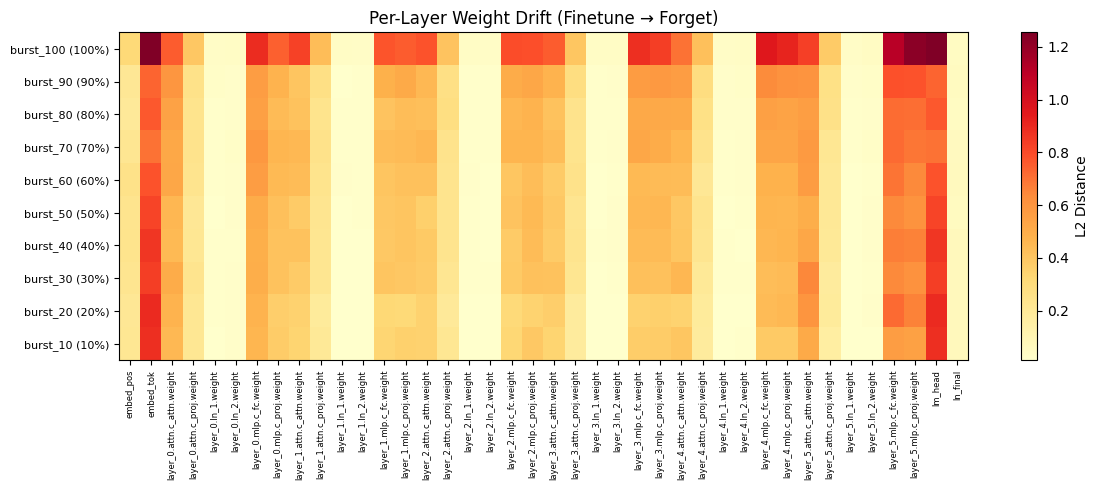

In [24]:
# Per-layer weight drift heatmaps
fig = report.plot_per_layer_drift(analysis, "pt_ft")
plt.show()

fig = report.plot_per_layer_drift(analysis, "ft_fg")
plt.show()

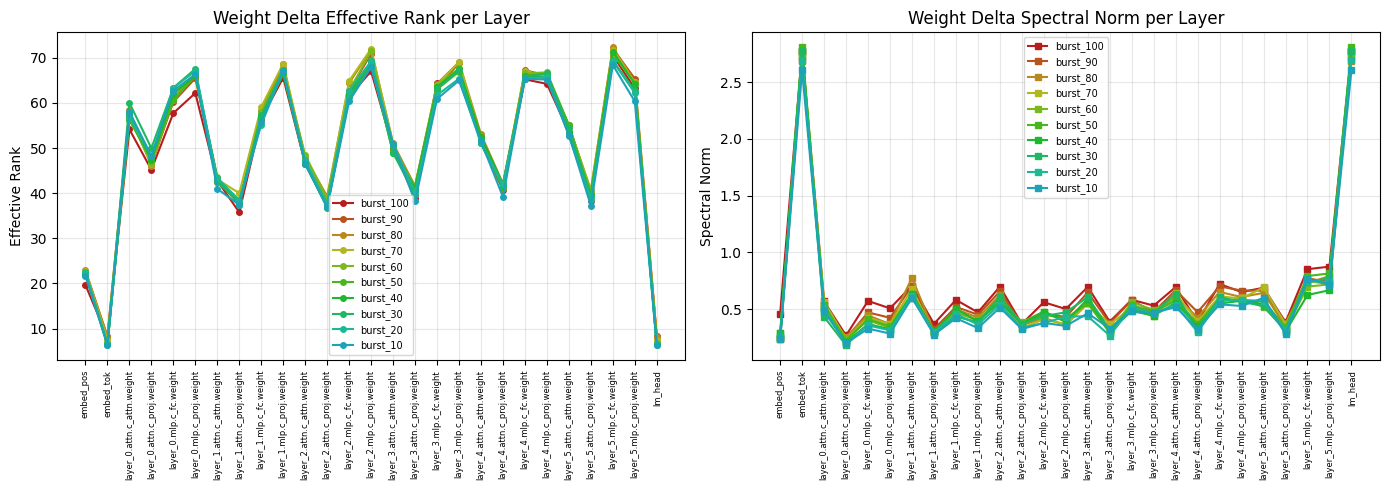

In [25]:
# SVD analysis: effective rank and spectral norm of weight deltas
fig = report.plot_svd_analysis(analysis)
plt.show()

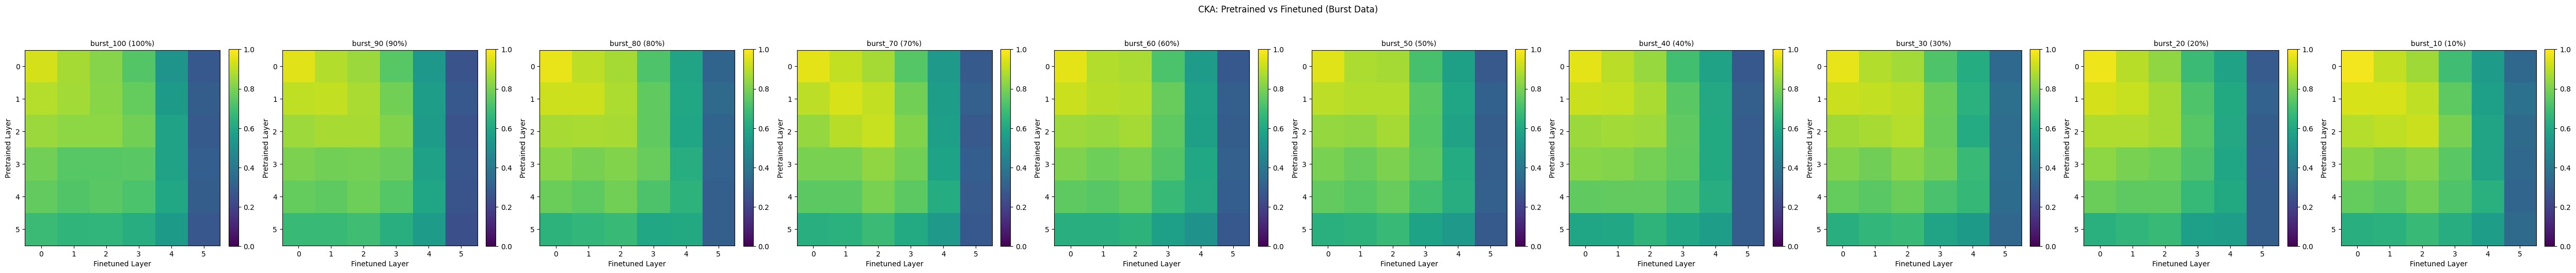

In [26]:
# CKA: representation similarity between pretrained and finetuned models
fig = report.plot_cka_matrices(analysis)
plt.show()

## 7. Summary Dashboard & Full Report

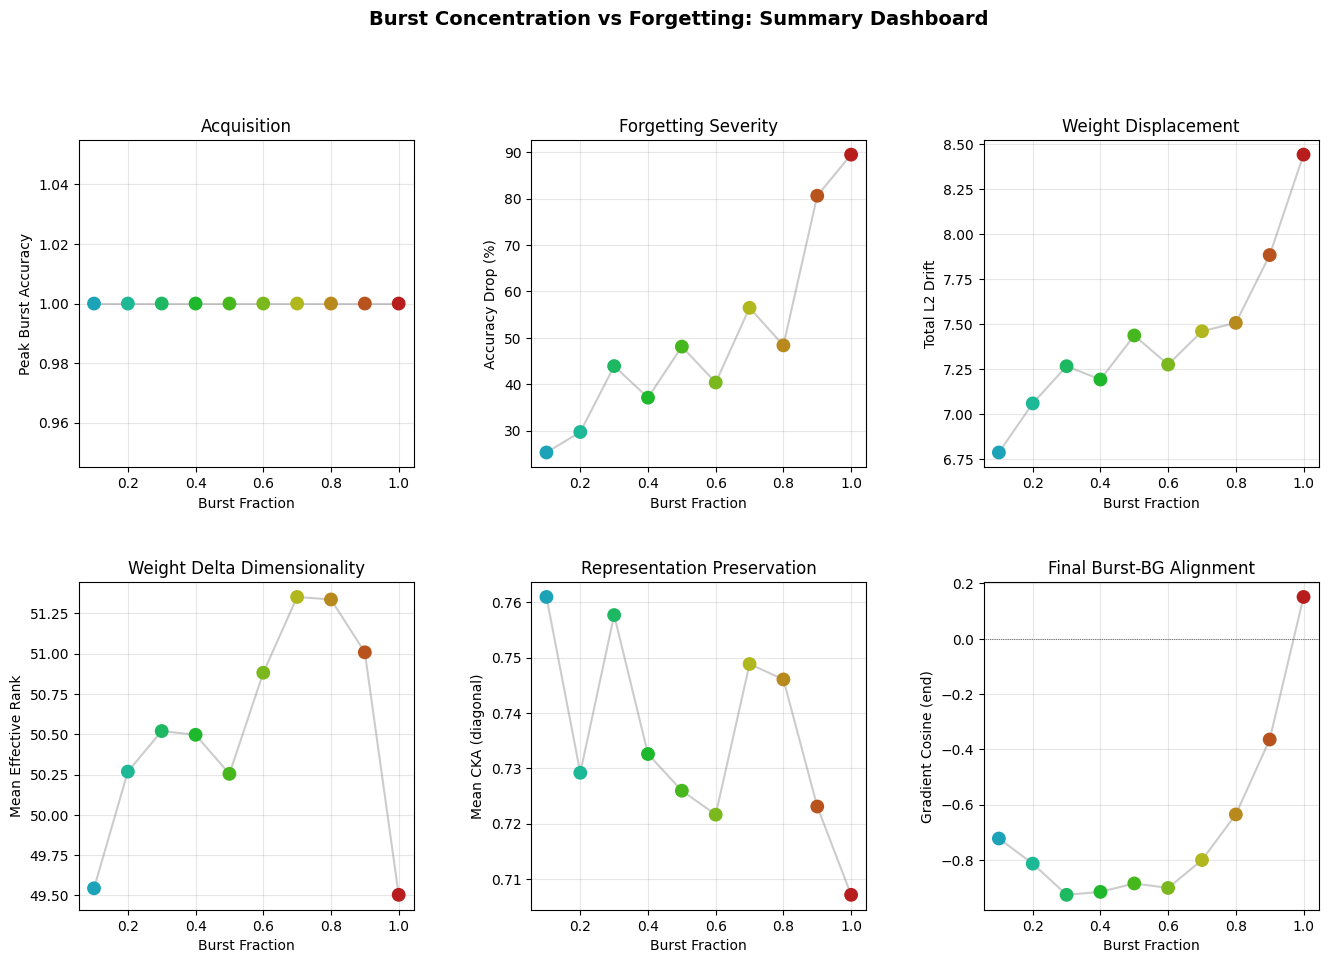

In [27]:
# Summary dashboard: all key metrics vs burst fraction
fig = report.plot_summary_dashboard(ft_results, fg_results, analysis)
plt.show()

In [ ]:
# Save all charts to disk
report.save_report(pt, ft_results, fg_results, f"{OUT}/report", analysis=analysis)